Estrategias disponibles:
 - alex
 - bea
 - chloe
 - dirac
 - random
Elija la estrategia para el Jugador 1: dirac
Elija la estrategia para el Jugador 2: random

Historial de movimientos:
dirac: ['C', 'C', 'C', 'C', 'D', 'C', 'C', 'C', 'C', 'C']
random: ['D', 'C', 'D', 'D', 'C', 'D', 'C', 'C', 'D', 'D']
Puntuación final de dirac: 39
Puntuación final de random: 14


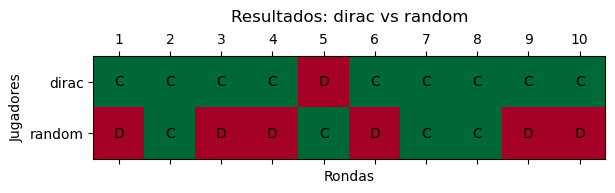

In [19]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Estrategias específicas
def alex(history, opponent_history):
    if 'D' in opponent_history:
        return 'D'
    return 'C'

def bea(history, opponent_history):
    if len(history) == 0:
        return random.choice(['C', 'D'])
    
    if len(history) > 0:
        last_move = history[-1]
        last_opponent_move = opponent_history[-1]
        
        if last_move == 'C' and last_opponent_move == 'D':
            return 'C'
        elif last_move == 'D' and last_opponent_move == 'C':
            return 'C'
        elif last_move == 'C' and last_opponent_move == 'C':
            return 'D'
        elif last_move == 'D' and last_opponent_move == 'D':
            return 'C'

    return random.choice(['C', 'D'])

def chloe(history, opponent_history):
    if not opponent_history:
        return 'C'
    return opponent_history[-1]

def dirac(history, opponent_history):
    if len(opponent_history) < 2:
        return 'C'
    if opponent_history[-2:] == ['D', 'D']:
        return 'D'
    return 'C'

def random_strategy(history, opponent_history):
    return random.choice(['C', 'D'])

def evaluate_scores(move1, move2):
    if move1 == 'C' and move2 == 'C':
        return 3, 3
    elif move1 == 'C' and move2 == 'D':
        return 5, 0
    elif move1 == 'D' and move2 == 'C':
        return 0, 5
    else:  # Ambos traicionan
        return 1, 1

# Mapeo de estrategias
strategies = {
    'alex': alex,
    'bea': bea,
    'chloe': chloe,
    'dirac': dirac,
    'random': random_strategy,
}

def simulate_game(strategy1, strategy2, rounds=10):
    history1 = []
    history2 = []
    
    initial_move1 = random.choice(['C', 'D'])
    initial_move2 = random.choice(['C', 'D'])
    history1.append(initial_move1)
    history2.append(initial_move2)
    
    score1, score2 = evaluate_scores(initial_move1, initial_move2)
    total_score1 = score1
    total_score2 = score2

    for _ in range(1, rounds):
        move1 = strategy1(history1, history2)
        move2 = strategy2(history2, history1)

        history1.append(move1)
        history2.append(move2)

        round_score1, round_score2 = evaluate_scores(move1, move2)
        total_score1 += round_score1
        total_score2 += round_score2

    return history1, history2, total_score1, total_score2

def plot_results(history1, history2, strategy1_name, strategy2_name):
    data = np.zeros((2, 10), dtype=int)  # Dos filas, diez columnas

    for i in range(10):
        data[0, i] = 1 if history1[i] == 'C' else 0
        data[1, i] = 1 if history2[i] == 'C' else 0

    fig, ax = plt.subplots()
    cax = ax.matshow(data, cmap='RdYlGn', vmin=0, vmax=1)

    for (i, j), val in np.ndenumerate(data):
        ax.text(j, i, 'C' if val == 1 else 'D', ha='center', va='center', color='black')

    plt.xlabel('Rondas')
    plt.ylabel('Jugadores')
    plt.title(f'Resultados: {strategy1_name} vs {strategy2_name}', pad=25)
    plt.xticks(range(10), list(range(1, 11)))
    plt.yticks([0, 1], [strategy1_name, strategy2_name])

    # Ajustar el espacio para evitar solapamiento
    plt.subplots_adjust(left=0.1, right=0.9, top=0.85, bottom=0.3)

    plt.show()

def main():
    print("Estrategias disponibles:")
    for strategy in strategies.keys():
        print(f" - {strategy}")

    strategy1_name = input("Elija la estrategia para el Jugador 1: ")
    strategy2_name = input("Elija la estrategia para el Jugador 2: ")

    if strategy1_name not in strategies or strategy2_name not in strategies:
        print("Estrategia no válida. Asegúrate de elegir una estrategia de la lista.")
        return

    strategy1 = strategies[strategy1_name]
    strategy2 = strategies[strategy2_name]

    history1, history2, final_score1, final_score2 = simulate_game(strategy1, strategy2)

    print("\nHistorial de movimientos:")
    print(f"{strategy1_name}: {history1}")
    print(f"{strategy2_name}: {history2}")
    print(f"Puntuación final de {strategy1_name}: {final_score1}")
    print(f"Puntuación final de {strategy2_name}: {final_score2}")

    plot_results(history1, history2, strategy1_name, strategy2_name)

if __name__ == "__main__":
    main()
